# Federated Learning - Kronolojik Eğitim

## Yapı
- **3 client** (User 1, 2, 3), her biri kendi telefonundaki verileri tutuyor
- **6 round**, her round'da 5 günlük veri penceresi (30 gün / 6 = 5 gün)
- Her round: Global model dağıtılır → Client'lar local eğitim yapar → FedAvg ile aggregate

## Parametreler
| Parametre | Değer |
|-----------|-------|
| Round | 6 |
| Veri/round | 5 gün (~350 kayıt/client) |
| Local epochs | 20 |
| Batch size | 32 |
| Learning rate | 0.01 |
| Aggregation | FedAvg (eşit ağırlıklı ortalama) |

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import json
import math
import os
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Device: cpu


## 1. Veri Yükleme ve Kronolojik Pencereler

30 günü 6 pencereye bölüyoruz. Her pencere 5 gün.

In [2]:
APP_TO_IDX = {
    "com.instagram.android": 0,
    "com.google.android.youtube": 1,
    "com.linkedin.android": 2,
    "com.whatsapp": 3
}
IDX_TO_LABEL = {0: "Instagram", 1: "YouTube", 2: "LinkedIn", 3: "WhatsApp"}
LOCAL_TZ = "Europe/Istanbul"
NUM_ROUNDS = 6
DAYS_PER_ROUND = 5

USER_FILES = {
    "user1": "app_usage_data_user1.csv",
    "user2": "app_usage_data_user2.csv",
    "user3": "app_usage_data_user3.csv"
}

def load_full_data(csv_path):
    df = pd.read_csv(csv_path)
    df["datetime"] = (
        pd.to_datetime(df["timestamp"], unit="ms", utc=True)
          .dt.tz_convert(LOCAL_TZ)
    )
    df["date"] = df["datetime"].dt.date
    df["hour"] = df["datetime"].dt.hour + df["datetime"].dt.minute / 60.0
    df["sin_hour"] = np.sin(2 * np.pi * df["hour"] / 24.0)
    df["cos_hour"] = np.cos(2 * np.pi * df["hour"] / 24.0)
    df["label"] = df["packageName"].map(APP_TO_IDX)
    return df

def split_by_days(df, days_per_round=5):
    """Kronolojik olarak gün bazlı pencerelere böler."""
    all_days = sorted(df["date"].unique())
    windows = []
    for i in range(0, len(all_days), days_per_round):
        window_days = all_days[i:i + days_per_round]
        window_df = df[df["date"].isin(window_days)]
        X = window_df[["sin_hour", "cos_hour"]].values.astype(np.float32)
        y = window_df["label"].values.astype(np.int64)
        windows.append({
            "X": X, "y": y,
            "days": window_days,
            "n_records": len(X)
        })
    return windows

user_windows = {}
for user, path in USER_FILES.items():
    df = load_full_data(path)
    windows = split_by_days(df, DAYS_PER_ROUND)
    user_windows[user] = windows
    print(f"\n{user}: {len(windows)} pencere")
    for i, w in enumerate(windows):
        print(f"  Round {i+1}: Gun {w['days'][0]} -> {w['days'][-1]} ({w['n_records']} kayit)")


user1: 6 pencere
  Round 1: Gun 2026-01-19 -> 2026-01-23 (376 kayit)
  Round 2: Gun 2026-01-24 -> 2026-01-28 (374 kayit)
  Round 3: Gun 2026-01-29 -> 2026-02-02 (376 kayit)
  Round 4: Gun 2026-02-03 -> 2026-02-07 (397 kayit)
  Round 5: Gun 2026-02-08 -> 2026-02-12 (365 kayit)
  Round 6: Gun 2026-02-13 -> 2026-02-17 (401 kayit)

user2: 6 pencere
  Round 1: Gun 2026-01-19 -> 2026-01-23 (354 kayit)
  Round 2: Gun 2026-01-24 -> 2026-01-28 (371 kayit)
  Round 3: Gun 2026-01-29 -> 2026-02-02 (351 kayit)
  Round 4: Gun 2026-02-03 -> 2026-02-07 (344 kayit)
  Round 5: Gun 2026-02-08 -> 2026-02-12 (376 kayit)
  Round 6: Gun 2026-02-13 -> 2026-02-17 (332 kayit)

user3: 6 pencere
  Round 1: Gun 2026-01-19 -> 2026-01-23 (371 kayit)
  Round 2: Gun 2026-01-24 -> 2026-01-28 (352 kayit)
  Round 3: Gun 2026-01-29 -> 2026-02-02 (357 kayit)
  Round 4: Gun 2026-02-03 -> 2026-02-07 (365 kayit)
  Round 5: Gun 2026-02-08 -> 2026-02-12 (365 kayit)
  Round 6: Gun 2026-02-13 -> 2026-02-17 (361 kayit)


## 2. Model + Local Training + FedAvg

In [3]:
class AppUsageModel(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=16, output_dim=4):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.model(x)

    def predict_proba(self, x):
        with torch.no_grad():
            logits = self.forward(x)
            return torch.softmax(logits, dim=1)


def local_train(global_state_dict, X, y, local_epochs=20, batch_size=32, lr=0.01):
    """
    Client tarafinda local egitim.
    Global model weight'lerinden baslar, local veriyle egitir, guncel weight dondurur.
    """
    model = AppUsageModel().to(device)
    model.load_state_dict(copy.deepcopy(global_state_dict))

    X_t = torch.FloatTensor(X).to(device)
    y_t = torch.LongTensor(y).to(device)

    dataset = TensorDataset(X_t, y_t)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999))

    model.train()
    for epoch in range(local_epochs):
        for batch_X, batch_y in loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_t).argmax(dim=1)
        acc = (preds == y_t).float().mean().item()

    return model.state_dict(), acc, len(X)


def fed_avg(client_state_dicts, client_sizes):
    """
    FedAvg: Client weight'lerini veri buyuklugune gore agirlikli ortalama ile birlestirir.
    """
    total = sum(client_sizes)
    weights = [s / total for s in client_sizes]

    avg_state = {}
    for key in client_state_dicts[0]:
        avg_state[key] = sum(
            w * client_state_dicts[i][key].float()
            for i, w in enumerate(weights)
        )
    return avg_state


def predict_for_hours(model, hours):
    """24 saat icin tahmin tablosu olusturur."""
    results = []
    model.eval()
    for h in hours:
        sin_h = math.sin(2 * math.pi * h / 24.0)
        cos_h = math.cos(2 * math.pi * h / 24.0)
        x = torch.FloatTensor([[sin_h, cos_h]]).to(device)
        probs = model.predict_proba(x)[0].cpu().numpy()
        pred_idx = probs.argmax()
        results.append({
            "hour": h, "prediction": IDX_TO_LABEL[pred_idx],
            "confidence": probs[pred_idx], "probs": probs
        })
    return results


def print_predictions(results, title=""):
    """Tahmin tablosunu yazdirir."""
    if title:
        print(title)
    print(f" {'saat':>5}  {'tahmin':>9} {'guven':>5}  {'Insta':>6} {'YT':>6} {'Link':>6} {'WA':>6}")
    for r in results:
        p = r["probs"]
        print(f" {r['hour']:02d}:00  {r['prediction']:>9} {r['confidence']*100:4.1f}%  "
              f"{p[0]*100:5.1f}% {p[1]*100:5.1f}% {p[2]*100:5.1f}% {p[3]*100:5.1f}%")


print("Model parametreleri:", sum(p.numel() for p in AppUsageModel().parameters()))

Model parametreleri: 388


## 3. Federated Learning - 6 Round

Her round sonunda global modelin 24-saat predict tablosunu basıyoruz.

In [4]:

import pickle

global_model  = AppUsageModel().to(device)
global_state  = global_model.state_dict()
round_history = []
delta_history = {}   # {round_idx: {user: {param_name: tensor}}}

for r in range(NUM_ROUNDS):
    print(f"\n{'#'*70}")
    print(f"  ROUND {r+1}/{NUM_ROUNDS}")
    print(f"{'#'*70}")

    client_states    = []
    client_sizes     = []
    delta_history[r] = {}

    for user in ["user1", "user2", "user3"]:
        window = user_windows[user][r]
        X, y   = window["X"], window["y"]
        days   = window["days"]

        w_before = copy.deepcopy(global_state)
        state, acc, n = local_train(global_state, X, y, local_epochs=20, batch_size=32, lr=0.01)

        # Her client'in bu round'daki parametrik katkisi: w_after - w_before
        delta_history[r][user] = {
            k: state[k].float() - w_before[k].float() for k in w_before
        }

        client_states.append(state)
        client_sizes.append(n)
        print(f"  {user}: Gun {days[0]}..{days[-1]} | {n:3d} kayit | Local Acc: {acc*100:.1f}%")

    global_state = fed_avg(client_states, client_sizes)
    global_model.load_state_dict(global_state)
    global_model.eval()

    results = predict_for_hours(global_model, range(24))
    round_history.append({"round": r+1, "results": results, "state": copy.deepcopy(global_state)})

    print(f"\n  --- Global Model (Round {r+1}) Tahminleri ---")
    print_predictions(results)

os.makedirs("results", exist_ok=True)
with open("delta_history.pkl", "wb") as f:
    pickle.dump(delta_history, f)

print(f"\n{'#'*70}")
print(f"  FEDERATED LEARNING TAMAMLANDI")
print(f"  delta_history.pkl: {NUM_ROUNDS} round, {len(delta_history[0])} client/round kaydedildi")
print(f"{'#'*70}")



######################################################################
  ROUND 1/6
######################################################################


  user1: Gun 2026-01-19..2026-01-23 | 376 kayit | Local Acc: 41.0%


  user2: Gun 2026-01-19..2026-01-23 | 354 kayit | Local Acc: 43.5%


  user3: Gun 2026-01-19..2026-01-23 | 371 kayit | Local Acc: 57.4%

  --- Global Model (Round 1) Tahminleri ---
  saat     tahmin guven   Insta     YT   Link     WA
 00:00    YouTube 40.2%   27.8%  40.2%   4.6%  27.5%
 01:00    YouTube 41.0%   22.0%  41.0%   5.5%  31.5%
 02:00    YouTube 41.8%   17.5%  41.8%   5.8%  34.8%
 03:00    YouTube 42.4%   16.0%  42.4%   5.2%  36.5%
 04:00    YouTube 41.7%   16.5%  41.7%   4.3%  37.5%
 05:00    YouTube 39.6%   19.1%  39.6%   3.5%  37.8%
 06:00   WhatsApp 38.2%   21.5%  37.3%   3.0%  38.2%
 07:00   WhatsApp 37.5%   25.6%  34.2%   2.8%  37.5%
 08:00   WhatsApp 35.9%   30.0%  31.3%   2.8%  35.9%
 09:00   WhatsApp 35.3%   30.9%  29.0%   4.8%  35.3%
 10:00   WhatsApp 32.9%   31.5%  26.3%   9.3%  32.9%
 11:00   WhatsApp 31.4%   26.5%  25.9%  16.1%  31.4%
 12:00   WhatsApp 32.1%   23.2%  22.4%  22.3%  32.1%
 13:00   WhatsApp 33.3%   20.8%  19.1%  26.8%  33.3%
 14:00   WhatsApp 33.2%   18.8%  17.5%  30.4%  33.2%
 15:00   WhatsApp 32.7%   19.4%  17.0%  

  user1: Gun 2026-01-24..2026-01-28 | 374 kayit | Local Acc: 41.7%


...

  user2: Gun 2026-02-08..2026-02-12 | 376 kayit | Local Acc: 49.2%


  user3: Gun 2026-02-08..2026-02-12 | 365 kayit | Local Acc: 61.1%

  --- Global Model (Round 5) Tahminleri ---
  saat     tahmin guven   Insta     YT   Link     WA
 00:00  Instagram 40.2%   40.2%  23.6%   5.4%  30.8%
 01:00  Instagram 37.2%   37.2%  24.2%   8.0%  30.6%
 02:00  Instagram 34.3%   34.3%  23.6%  11.0%  31.1%
 03:00   WhatsApp 35.0%   27.6%  25.2%  12.3%  35.0%
 04:00   WhatsApp 36.5%   24.2%  24.9%  14.4%  36.5%
 05:00   WhatsApp 36.1%   24.7%  24.1%  15.1%  36.1%
 06:00   WhatsApp 36.1%   30.5%  22.0%  11.4%  36.1%
 07:00   WhatsApp 38.1%   35.0%  20.0%   6.9%  38.1%
 08:00   WhatsApp 45.7%   30.8%  18.9%   4.6%  45.7%
 09:00   WhatsApp 55.3%    8.8%  26.6%   9.3%  55.3%
 10:00   LinkedIn 34.5%   13.6%  22.7%  34.5%  29.2%
 11:00   WhatsApp 28.3%   20.6%  23.3%  27.8%  28.3%
 12:00  Instagram 27.9%   27.9%  20.2%  24.9%  27.0%
 13:00  Instagram 42.4%   42.4%  13.6%  20.4%  23.6%
 14:00   WhatsApp 30.3%   28.2%  12.7%  28.7%  30.3%
 15:00   LinkedIn 40.7%   10.3%  11.5%  

  user1: Gun 2026-02-13..2026-02-17 | 401 kayit | Local Acc: 44.4%


  user2: Gun 2026-02-13..2026-02-17 | 332 kayit | Local Acc: 48.8%


  user3: Gun 2026-02-13..2026-02-17 | 361 kayit | Local Acc: 60.4%

  --- Global Model (Round 6) Tahminleri ---
  saat     tahmin guven   Insta     YT   Link     WA
 00:00  Instagram 37.3%   37.3%  27.4%   5.5%  29.8%
 01:00  Instagram 44.7%   44.7%  24.5%   6.2%  24.7%
 02:00    YouTube 35.1%   23.8%  35.1%   6.8%  34.3%
 03:00   WhatsApp 38.9%   15.2%  38.0%   8.0%  38.9%
 04:00   WhatsApp 40.1%   12.8%  36.4%  10.6%  40.1%
 05:00   WhatsApp 39.3%   13.7%  35.5%  11.5%  39.3%
 06:00    YouTube 34.8%   22.0%  34.8%   8.6%  34.6%
 07:00  Instagram 40.2%   40.2%  30.5%   3.2%  26.0%
 08:00  Instagram 46.3%   46.3%  25.8%   1.1%  26.8%
 09:00   WhatsApp 41.2%   25.9%  29.9%   3.0%  41.2%
 10:00   LinkedIn 32.1%   26.5%  17.1%  32.1%  24.4%
 11:00   LinkedIn 30.2%   27.6%  17.3%  30.2%  24.8%
 12:00   LinkedIn 32.4%   24.0%  18.3%  32.4%  25.3%
 13:00  Instagram 36.7%   36.7%  17.7%  24.4%  21.3%
 14:00   LinkedIn 31.2%   21.4%  19.7%  31.2%  27.7%
 15:00   LinkedIn 37.0%   10.9%  16.5%  

## 4. Final Global Model - Detaylı Karşılaştırma

Her kullanıcının beklenen pattern'lerine karşı final global modelin tahminleri.

In [5]:
expected_patterns = {
    "user1": "08-10: %100 Instagram | 14-18: LinkedIn+WhatsApp | 18-20: YouTube+Instagram",
    "user2": "08-10: %100 YouTube | 12-14: %100 Instagram | 14-18: LinkedIn+WhatsApp",
    "user3": "08-10: %100 WhatsApp | 18-22: %100 YouTube | 22-02: Instagram"
}

print("="*70)
print("  FINAL GLOBAL MODEL vs BIREYSEL BEKLENTILER")
print("="*70)

final_results = round_history[-1]["results"]

for user, pattern in expected_patterns.items():
    print(f"\n  {user.upper()} beklentisi: {pattern}")

print(f"\n{'='*70}")
print(f"  GLOBAL MODEL - 24 SAAT TAHMIN TABLOSU")
print(f"{'='*70}")
print_predictions(final_results)

print(f"\n{'='*70}")
print("  SABIT ETKI SAATLERI - OZET")
print(f"{'='*70}")

checks = [
    ("08:00-10:00", [8, 9], {
        "user1": "Instagram",
        "user2": "YouTube",
        "user3": "WhatsApp"
    }),
    ("12:00-14:00", [12, 13], {
        "user2": "Instagram"
    }),
    ("18:00-22:00", [18, 19, 20, 21], {
        "user3": "YouTube"
    }),
]

for label, hours, user_expected in checks:
    print(f"\n  {label}:")
    for h in hours:
        r = final_results[h]
        p = r["probs"]
        expected_apps = [f"{u}: {app}" for u, app in user_expected.items()]
        print(f"    {h:02d}:00 -> {r['prediction']} ({r['confidence']*100:.1f}%)  "
              f"[Insta:{p[0]*100:.0f}% YT:{p[1]*100:.0f}% Link:{p[2]*100:.0f}% WA:{p[3]*100:.0f}%]  "
              f"Beklenen: {', '.join(expected_apps)}")

  FINAL GLOBAL MODEL vs BIREYSEL BEKLENTILER

  USER1 beklentisi: 08-10: %100 Instagram | 14-18: LinkedIn+WhatsApp | 18-20: YouTube+Instagram

  USER2 beklentisi: 08-10: %100 YouTube | 12-14: %100 Instagram | 14-18: LinkedIn+WhatsApp

  USER3 beklentisi: 08-10: %100 WhatsApp | 18-22: %100 YouTube | 22-02: Instagram

  GLOBAL MODEL - 24 SAAT TAHMIN TABLOSU
  saat     tahmin guven   Insta     YT   Link     WA
 00:00  Instagram 37.3%   37.3%  27.4%   5.5%  29.8%
 01:00  Instagram 44.7%   44.7%  24.5%   6.2%  24.7%
 02:00    YouTube 35.1%   23.8%  35.1%   6.8%  34.3%
 03:00   WhatsApp 38.9%   15.2%  38.0%   8.0%  38.9%
 04:00   WhatsApp 40.1%   12.8%  36.4%  10.6%  40.1%
 05:00   WhatsApp 39.3%   13.7%  35.5%  11.5%  39.3%
 06:00    YouTube 34.8%   22.0%  34.8%   8.6%  34.6%
 07:00  Instagram 40.2%   40.2%  30.5%   3.2%  26.0%
 08:00  Instagram 46.3%   46.3%  25.8%   1.1%  26.8%
 09:00   WhatsApp 41.2%   25.9%  29.9%   3.0%  41.2%
 10:00   LinkedIn 32.1%   26.5%  17.1%  32.1%  24.4%
 11:00

## 5. Round Bazlı Evrim - Sabit Saatlerin Değişimi

Her round sonunda kritik saatlerdeki tahminlerin nasıl değiştiğini takip edelim.

In [6]:
critical_hours = {
    9: "08-10 blogu (U1:Insta, U2:YT, U3:WA)",
    13: "12-14 blogu (U2:Insta)",
    20: "18-22 blogu (U3:YT)",
    0: "22-02 blogu (U3:Insta)"
}

print("="*70)
print("  ROUND BAZLI EVRIM - KRITIK SAATLER")
print("="*70)

for hour, desc in critical_hours.items():
    print(f"\n  Saat {hour:02d}:00 - {desc}")
    print(f"  {'Round':>5}  {'Tahmin':>9}  {'Insta':>6} {'YT':>6} {'Link':>6} {'WA':>6}")
    for rh in round_history:
        r = rh["results"][hour]
        p = r["probs"]
        print(f"  R{rh['round']:>4}  {r['prediction']:>9}  "
              f"{p[0]*100:5.1f}% {p[1]*100:5.1f}% {p[2]*100:5.1f}% {p[3]*100:5.1f}%")

  ROUND BAZLI EVRIM - KRITIK SAATLER

  Saat 09:00 - 08-10 blogu (U1:Insta, U2:YT, U3:WA)
  Round     Tahmin   Insta     YT   Link     WA
  R   1   WhatsApp   30.9%  29.0%   4.8%  35.3%
  R   2   WhatsApp   18.1%  32.1%   3.4%  46.3%
  R   3   WhatsApp   22.4%  26.3%   6.0%  45.4%
  R   4   WhatsApp   13.7%  27.8%   4.1%  54.4%
  R   5   WhatsApp    8.8%  26.6%   9.3%  55.3%
  R   6   WhatsApp   25.9%  29.9%   3.0%  41.2%

  Saat 13:00 - 12-14 blogu (U2:Insta)
  Round     Tahmin   Insta     YT   Link     WA
  R   1   WhatsApp   20.8%  19.1%  26.8%  33.3%
  R   2   LinkedIn   16.5%  11.3%  41.0%  31.2%
  R   3  Instagram   31.6%  13.8%  29.7%  24.8%
  R   4  Instagram   39.5%  16.3%  24.3%  19.9%
  R   5  Instagram   42.4%  13.6%  20.4%  23.6%
  R   6  Instagram   36.7%  17.7%  24.4%  21.3%

  Saat 20:00 - 18-22 blogu (U3:YT)
  Round     Tahmin   Insta     YT   Link     WA
  R   1    YouTube   25.1%  47.0%   4.8%  23.1%
  R   2    YouTube   17.4%  61.4%   4.3%  16.9%
  R   3    YouTube 

## 6. Global Model Ağırlıklarını Kaydet

In [7]:
os.makedirs("weights", exist_ok=True)

def save_weights_json(state_dict, filepath):
    serializable = {}
    for key, tensor in state_dict.items():
        serializable[key] = tensor.cpu().tolist()
    with open(filepath, "w") as f:
        json.dump(serializable, f, indent=2)
    print(f"  Kaydedildi: {filepath}")

for rh in round_history:
    save_weights_json(rh["state"], f"weights/global_round{rh['round']}_weights.json")

save_weights_json(round_history[-1]["state"], "weights/global_final_weights.json")

print("\nKaydedilen dosyalar:")
for f in sorted(os.listdir("weights")):
    if f.startswith("global"):
        size_kb = os.path.getsize(f"weights/{f}") / 1024
        print(f"  {f}: {size_kb:.1f} KB")

  Kaydedildi: weights/global_round1_weights.json
  Kaydedildi: weights/global_round2_weights.json
  Kaydedildi: weights/global_round3_weights.json
  Kaydedildi: weights/global_round4_weights.json
  Kaydedildi: weights/global_round5_weights.json
  Kaydedildi: weights/global_round6_weights.json
  Kaydedildi: weights/global_final_weights.json

Kaydedilen dosyalar:
  global_final_weights.json: 11.2 KB
  global_round1_weights.json: 11.3 KB
  global_round2_weights.json: 11.3 KB
  global_round3_weights.json: 11.2 KB
  global_round4_weights.json: 11.3 KB
  global_round5_weights.json: 11.2 KB
  global_round6_weights.json: 11.2 KB


## 7. Training Loss Evrimi

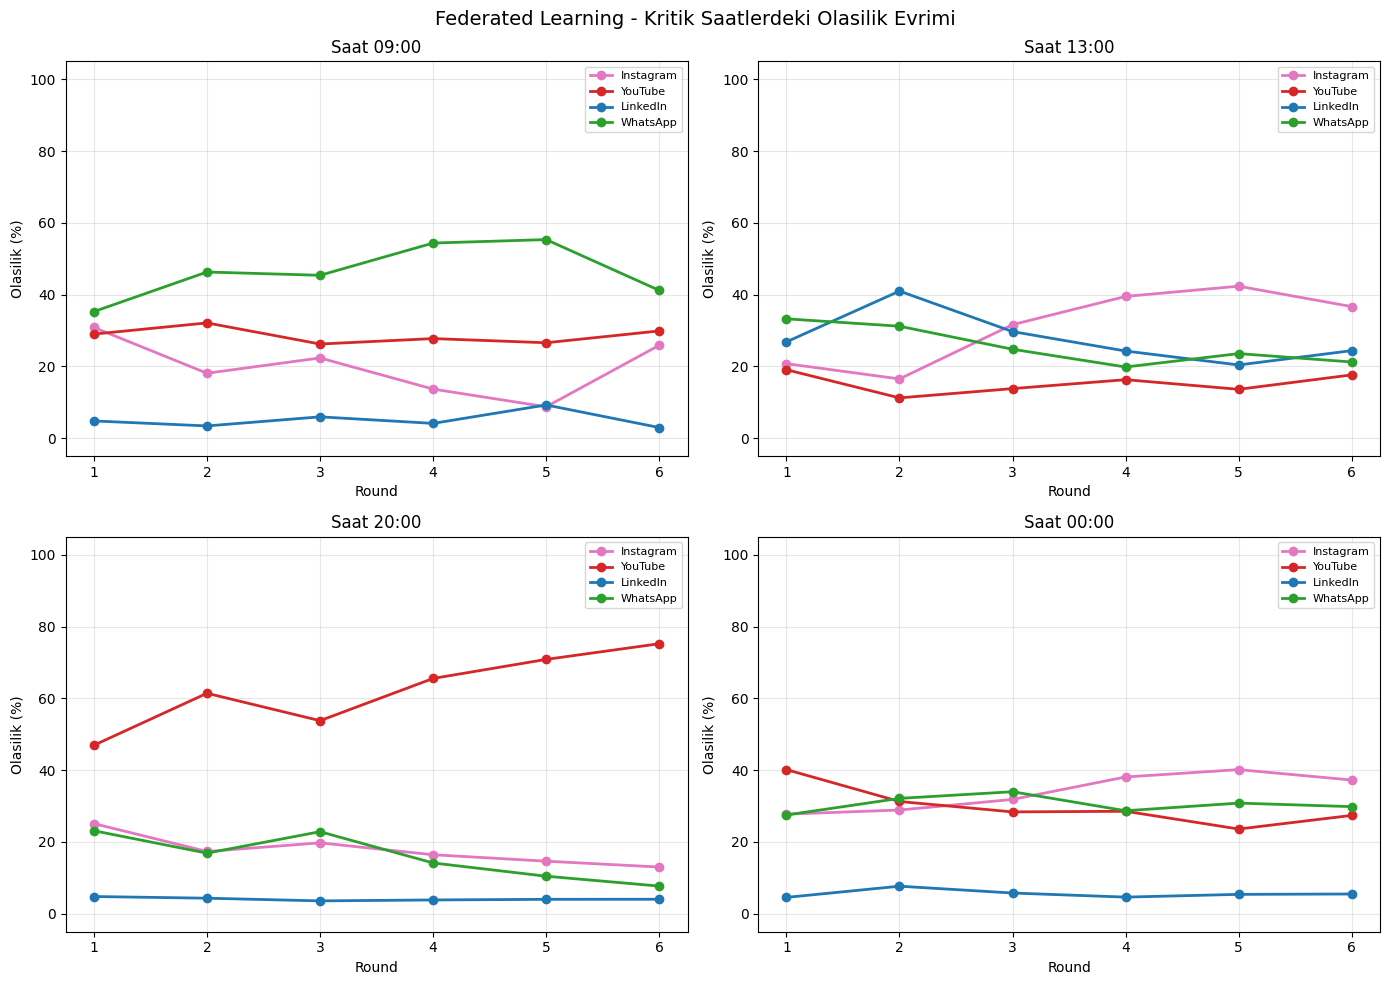

Grafik kaydedildi: fl_evolution.png


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

critical = {9: ("09:00", axes[0, 0]), 13: ("13:00", axes[0, 1]),
            20: ("20:00", axes[1, 0]), 0: ("00:00", axes[1, 1])}

app_colors = {"Instagram": "tab:pink", "YouTube": "tab:red",
              "LinkedIn": "tab:blue", "WhatsApp": "tab:green"}

for hour, (label, ax) in critical.items():
    rounds = [rh["round"] for rh in round_history]
    for app_idx, app_name in IDX_TO_LABEL.items():
        probs = [rh["results"][hour]["probs"][app_idx] * 100 for rh in round_history]
        ax.plot(rounds, probs, marker="o", label=app_name, color=app_colors[app_name], linewidth=2)
    ax.set_title(f"Saat {label}")
    ax.set_xlabel("Round")
    ax.set_ylabel("Olasilik (%)")
    ax.set_ylim(-5, 105)
    ax.set_xticks(rounds)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Federated Learning - Kritik Saatlerdeki Olasilik Evrimi", fontsize=14)
plt.tight_layout()
plt.savefig("fl_evolution.png", dpi=150)
plt.show()
print("Grafik kaydedildi: fl_evolution.png")

## 8. Machine Unlearning Experiments

Federated Learning sonrası **user1** (Instagram dominant, 08:00-10:00 bloğu) silinecek. İki yöntem karşılaştırılıyor:

| Yöntem | Çalışma Yeri | Algoritma | Açıklama |
|--------|--------------|-----------|----------|
| **Server-Based** | Sunucu | FedEraser (Liu et al. 2021) | Eğitim sırasında kaydedilen delta'lar global modelden çıkarılır |
| **Client-Based** | Client cihazı | Gradient Ascent | Client kendi verisinde loss'u maximize ederek parametrik izini siler |

**Delta History:** FL eğitimi esnasında her round'da her client'ın katkısı (`w_after − w_before`) real-time olarak kaydedildi ve `delta_history.pkl` dosyasına yazıldı.

In [9]:

import time, json
from datetime import datetime

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def analyze_8_to_10_predictions(model, user_name):
    """Gercek 8-10 saati veri noktalarini filtreleyip ortalama olasilik hesaplar."""
    df          = load_full_data(USER_FILES[user_name])
    df_filtered = df[(df["hour"] >= 8) & (df["hour"] < 10)]
    X = df_filtered[["sin_hour", "cos_hour"]].values.astype(np.float32)

    model.eval()
    X_t = torch.FloatTensor(X).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(X_t), dim=1).cpu().numpy()

    avg_probs = probs.mean(axis=0)
    return {
        "Instagram":    float(avg_probs[0]),
        "YouTube":      float(avg_probs[1]),
        "LinkedIn":     float(avg_probs[2]),
        "WhatsApp":     float(avg_probs[3]),
        "sample_count": int(len(X))
    }


def calculate_entropy(probs_dict):
    """entropy = -sum(p * log(p)).  Yuksek = belirsiz tahmin (unlearning basarili)."""
    probs = np.array([probs_dict["Instagram"], probs_dict["YouTube"],
                      probs_dict["LinkedIn"],  probs_dict["WhatsApp"]])
    probs = np.clip(probs, 1e-10, 1.0)
    return float(-np.sum(probs * np.log(probs)))


def calculate_accuracy(model, user_name):
    """Bir kullanicinin tum verisi uzerinde top-1 dogruluk hesaplar."""
    df  = load_full_data(USER_FILES[user_name])
    X   = df[["sin_hour", "cos_hour"]].values.astype(np.float32)
    y   = df["label"].values.astype(np.int64)
    X_t = torch.FloatTensor(X).to(device)
    y_t = torch.LongTensor(y).to(device)
    model.eval()
    with torch.no_grad():
        preds = model(X_t).argmax(dim=1)
        acc   = (preds == y_t).float().mean().item()
    return float(acc)


print("Helper fonksiyonlar tanimlandi: analyze_8_to_10_predictions, calculate_entropy, calculate_accuracy")


Helper fonksiyonlar tanimlandi: analyze_8_to_10_predictions, calculate_entropy, calculate_accuracy


## 9. Aşama 1: Server-Based Unlearning (FedEraser)

**Algoritma:** FedEraser (Liu et al. 2021)  
**Çalışma yeri:** Sunucu — client katılımı gerekmez

FL eğitimi esnasında her client'ın her round'daki parametrik katkısı (`delta = w_after − w_before`) kaydedildi. Unlearning işlemi bu delta'ların global modelden çıkarılmasıyla gerçekleşir:

```
total_delta = Σ_t  delta_history[t][forget_user]   (saf toplam, tüm round'lar)
unlearned_weights = global_weights − total_delta
```

**Avantajlar:** Anlık (matris çıkarma), matematiksel olarak exact, ölçeklenebilir.  
**Ön koşul:** `delta_history.pkl` — FL eğitimi esnasında real-time kaydedildi.

In [10]:
def server_based_fedraser(global_state, forget_user, remaining_users, delta_history,
                          recovery_rounds=3, recovery_epochs=5):
    """
    FedEraser (Liu et al. 2021) - Server-Side Unlearning.

    Iki asama (sureler ayri olarak raporlanir):
      Step 1: Delta-guided parameter subtraction (anlik, ms duzeyinde)
      Step 2: Recovery rounds (u2+u3 ile recovery_rounds defa FedAvg)
    """
    pipeline_start = time.time()
    print("-" * 55)
    print("  ASAMA 1: SERVER-BASED UNLEARNING (FedEraser)")
    print("-" * 55)
    print(f"\n  Forget user      : {forget_user}")
    print(f"  Remaining users  : {remaining_users}")
    print(f"  Round sayisi     : {len(delta_history)}")
    print(f"  Recovery rounds  : {recovery_rounds} x {recovery_epochs} epoch")
    print()

    ALL_USERS = [forget_user] + list(remaining_users)

    # --- Step 1: Delta subtraction ---
    step1_start = time.time()
    print("Step 1: Delta-guided parameter subtraction")
    correction = {k: torch.zeros_like(global_state[k].float()) for k in global_state}
    for r in range(len(delta_history)):
        delta_r  = delta_history[r][forget_user]
        n_forget = user_windows[forget_user][r]["n_records"]
        n_total  = sum(user_windows[u][r]["n_records"] for u in ALL_USERS)
        w_forget = n_forget / n_total
        norm_r   = sum(v.norm().item() for v in delta_r.values())
        print(f"  Round {r}: delta norm = {norm_r:.4f}, w_forget = {w_forget:.3f}")
        for k in correction:
            correction[k] = correction[k] + w_forget * delta_r[k].float()

    correction_norm = sum(v.norm().item() for v in correction.values())
    print(f"\n  Toplam correction norm  : {correction_norm:.4f}")

    corrected_state = {
        k: global_state[k].float() - correction[k]
        for k in global_state
    }
    step1_time = time.time() - step1_start
    print(f"  Step 1 suresi: {step1_time:.4f} s")

    # --- Step 2: Recovery rounds (u2+u3 ile yeniden FedAvg) ---
    step2_start = time.time()
    print(f"\nStep 2: Recovery Rounds")
    recovery_state        = corrected_state
    recovery_loss_history = []

    for rr in range(recovery_rounds):
        print(f"  Recovery Round {rr+1}/{recovery_rounds}:")
        rec_states   = []
        rec_sizes    = []
        round_losses = []

        for user in remaining_users:
            X_u = np.vstack([user_windows[user][r]["X"] for r in range(NUM_ROUNDS)])
            y_u = np.hstack([user_windows[user][r]["y"] for r in range(NUM_ROUNDS)])
            state, acc, n = local_train(recovery_state, X_u, y_u,
                                        local_epochs=recovery_epochs, batch_size=32, lr=0.01)
            rec_states.append(state)
            rec_sizes.append(n)

            _m = AppUsageModel().to(device)
            _m.load_state_dict(state)
            _m.eval()
            with torch.no_grad():
                out  = _m(torch.FloatTensor(X_u).to(device))
                loss = nn.CrossEntropyLoss()(out, torch.LongTensor(y_u).to(device)).item()
            round_losses.append(loss)
            print(f"    {user}: acc={acc*100:.1f}%, loss={loss:.4f}")

        recovery_state = fed_avg(rec_states, rec_sizes)
        avg_loss       = sum(round_losses) / len(round_losses)
        recovery_loss_history.append(avg_loss)
        print(f"    FedAvg yapildi | avg loss: {avg_loss:.4f}")

    step2_time = time.time() - step2_start
    total_time = time.time() - pipeline_start

    fedraser_model = AppUsageModel().to(device)
    fedraser_model.load_state_dict(recovery_state)
    fedraser_model.eval()

    print(f"\n  Step 1 suresi: {step1_time:.4f} s")
    print(f"  Step 2 suresi: {step2_time:.4f} s")
    print(f"  Toplam suresi: {total_time:.4f} s")

    return {
        "model"                : fedraser_model,
        "state"                : recovery_state,
        "total_delta_norm"     : correction_norm,
        "recovery_loss_history": recovery_loss_history,
        "step1_time"           : step1_time,
        "step2_time"           : step2_time,
        "total_time"           : total_time
    }


# --- RUN ---
FORGET_USER     = "user1"
REMAINING_USERS = ["user2", "user3"]

fedraser_results = server_based_fedraser(
    global_state    = global_state,
    forget_user     = FORGET_USER,
    remaining_users = REMAINING_USERS,
    delta_history   = delta_history,
    recovery_rounds = 3,
    recovery_epochs = 5
)
fedraser_model = fedraser_results["model"]


-------------------------------------------------------
  ASAMA 1: SERVER-BASED UNLEARNING (FedEraser)
-------------------------------------------------------

  Forget user      : user1
  Remaining users  : ['user2', 'user3']
  Round sayisi     : 6
  Recovery rounds  : 3 x 5 epoch

Step 1: Delta-guided parameter subtraction
  Round 0: delta norm = 9.1950, w_forget = 0.342
  Round 1: delta norm = 5.5893, w_forget = 0.341
  Round 2: delta norm = 5.6338, w_forget = 0.347
  Round 3: delta norm = 5.5500, w_forget = 0.359
  Round 4: delta norm = 5.1375, w_forget = 0.330
  Round 5: delta norm = 5.0892, w_forget = 0.367

  Toplam correction norm  : 8.9827
  Step 1 suresi: 0.0009 s

Step 2: Recovery Rounds
  Recovery Round 1/3:


    user2: acc=44.3%, loss=1.1537


    user3: acc=60.0%, loss=0.9285
    FedAvg yapildi | avg loss: 1.0411
  Recovery Round 2/3:


    user2: acc=43.9%, loss=1.1370


    user3: acc=59.8%, loss=0.9195
    FedAvg yapildi | avg loss: 1.0283
  Recovery Round 3/3:


    user2: acc=45.1%, loss=1.1381


    user3: acc=59.4%, loss=0.9110
    FedAvg yapildi | avg loss: 1.0246

  Step 1 suresi: 0.0009 s
  Step 2 suresi: 2.1492 s
  Toplam suresi: 2.1501 s


## 10. Aşama 2: Client-Based Unlearning (Gradient Ascent)

**Algoritma:** Gradient Ascent  
**Çalışma yeri:** Client cihazı — sunucu hiçbir şey saklamaz

Silinecek client kendi train verisini kullanarak modelin bu veriye verdiği cevabı bozar. Loss minimize edilmek yerine **maximize** edilir:

```python
loss.backward()
for param in model.parameters():
    param.grad = -param.grad   # gradient'leri ters cevir
optimizer.step()               # loss ARTACAK
```

> **SGD kullanılıyor (Adam değil):** Adam'ın adaptive moment'leri negatif gradient ile birleşince loss kontrolsüz büyür (önceki denemede 25 → 46705). SGD sabit lr ile bu riski taşımaz.

In [11]:
def client_based_gradient_ascent(global_state, forget_user, remaining_users,
                                  learning_rate=0.001, epochs=5,
                                  recovery_rounds=3, recovery_epochs=5):
    """
    Client-Based Unlearning via Gradient Ascent + Recovery.

    Iki asama (sureler ayri olarak raporlanir):
      Step 1: Gradient ascent (forget client uzerinde)
      Step 2: Recovery rounds (u2+u3 ile FedAvg, FedEraser ile birebir ayni)
    """
    pipeline_start = time.time()
    print("-" * 55)
    print("  ASAMA 2: CLIENT-BASED UNLEARNING (Gradient Ascent)")
    print("-" * 55)

    # --- Step 1: Gradient ascent ---
    step1_start = time.time()
    print("\nStep 1: Gradient Ascent (forget client)")
    df  = load_full_data(USER_FILES[forget_user])
    X   = df[["sin_hour", "cos_hour"]].values.astype(np.float32)
    y   = df["label"].values.astype(np.int64)
    X_t = torch.FloatTensor(X).to(device)
    y_t = torch.LongTensor(y).to(device)

    dataset = TensorDataset(X_t, y_t)
    loader  = DataLoader(dataset, batch_size=32, shuffle=True)

    ga_model = AppUsageModel().to(device)
    ga_model.load_state_dict(copy.deepcopy(global_state))

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(ga_model.parameters(), lr=learning_rate)

    print(f"  Forget user  : {forget_user} ({len(X)} kayit)")
    print(f"  Optimizer    : SGD (lr={learning_rate})")
    print(f"  Epochs       : {epochs}")

    loss_history = []
    ga_model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        n_batches  = 0
        for batch_X, batch_y in loader:
            outputs = ga_model(batch_X)
            loss    = criterion(outputs, batch_y)
            epoch_loss += loss.item()

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(ga_model.parameters(), max_norm=1.0)

            # FLIP: gradient ascent - loss'u artir
            for param in ga_model.parameters():
                if param.grad is not None:
                    param.grad = -param.grad

            optimizer.step()
            n_batches += 1

        avg_loss = epoch_loss / n_batches
        loss_history.append(avg_loss)
        print(f"  Epoch {epoch+1}/{epochs}: avg loss = {avg_loss:.4f}")

    print(f"  Loss degisimi: {loss_history[0]:.4f} -> {loss_history[-1]:.4f}")
    step1_time = time.time() - step1_start
    print(f"  Step 1 suresi: {step1_time:.4f} s")

    ga_state = ga_model.state_dict()

    # --- Step 2: Recovery rounds (FedEraser ile ayni) ---
    step2_start = time.time()
    print(f"\nStep 2: Recovery Rounds")
    recovery_state        = copy.deepcopy(ga_state)
    recovery_loss_history = []

    for rr in range(recovery_rounds):
        print(f"  Recovery Round {rr+1}/{recovery_rounds}:")
        rec_states   = []
        rec_sizes    = []
        round_losses = []

        for user in remaining_users:
            X_u = np.vstack([user_windows[user][r]["X"] for r in range(NUM_ROUNDS)])
            y_u = np.hstack([user_windows[user][r]["y"] for r in range(NUM_ROUNDS)])
            state, acc, n = local_train(recovery_state, X_u, y_u,
                                        local_epochs=recovery_epochs, batch_size=32, lr=0.01)
            rec_states.append(state)
            rec_sizes.append(n)

            _m = AppUsageModel().to(device)
            _m.load_state_dict(state)
            _m.eval()
            with torch.no_grad():
                out  = _m(torch.FloatTensor(X_u).to(device))
                loss = nn.CrossEntropyLoss()(out, torch.LongTensor(y_u).to(device)).item()
            round_losses.append(loss)
            print(f"    {user}: acc={acc*100:.1f}%, loss={loss:.4f}")

        recovery_state = fed_avg(rec_states, rec_sizes)
        avg_loss       = sum(round_losses) / len(round_losses)
        recovery_loss_history.append(avg_loss)
        print(f"    FedAvg yapildi | avg loss: {avg_loss:.4f}")

    step2_time = time.time() - step2_start
    total_time = time.time() - pipeline_start

    final_model = AppUsageModel().to(device)
    final_model.load_state_dict(recovery_state)
    final_model.eval()

    print(f"\n  Step 1 suresi: {step1_time:.4f} s")
    print(f"  Step 2 suresi: {step2_time:.4f} s")
    print(f"  Toplam suresi: {total_time:.4f} s")

    return {
        "model"                : final_model,
        "state"                : recovery_state,
        "loss_history"         : loss_history,
        "recovery_loss_history": recovery_loss_history,
        "step1_time"           : step1_time,
        "step2_time"           : step2_time,
        "total_time"           : total_time
    }


# --- RUN ---
ga_results = client_based_gradient_ascent(
    global_state    = global_state,
    forget_user     = FORGET_USER,
    remaining_users = REMAINING_USERS,
    learning_rate   = 0.001,
    epochs          = 5,
    recovery_rounds = 3,
    recovery_epochs = 5
)
ga_model = ga_results["model"]


-------------------------------------------------------
  ASAMA 2: CLIENT-BASED UNLEARNING (Gradient Ascent)
-------------------------------------------------------

Step 1: Gradient Ascent (forget client)
  Forget user  : user1 (2289 kayit)
  Optimizer    : SGD (lr=0.001)
  Epochs       : 5
  Epoch 1/5: avg loss = 1.3897
  Epoch 2/5: avg loss = 1.4425


  Epoch 3/5: avg loss = 1.5171


  Epoch 4/5: avg loss = 1.5983
  Epoch 5/5: avg loss = 1.6961
  Loss degisimi: 1.3897 -> 1.6961
  Step 1 suresi: 0.3420 s

Step 2: Recovery Rounds
  Recovery Round 1/3:


    user2: acc=44.5%, loss=1.1332


    user3: acc=60.4%, loss=0.9122
    FedAvg yapildi | avg loss: 1.0227
  Recovery Round 2/3:


    user2: acc=44.6%, loss=1.1254


    user3: acc=59.6%, loss=0.9126
    FedAvg yapildi | avg loss: 1.0190
  Recovery Round 3/3:


    user2: acc=44.6%, loss=1.1292


    user3: acc=58.6%, loss=0.9050
    FedAvg yapildi | avg loss: 1.0171

  Step 1 suresi: 0.3420 s
  Step 2 suresi: 2.5465 s
  Toplam suresi: 2.8887 s


## 11. Aşama 3: Karşılaştırma ve Analiz

Üç model (orijinal, server-based FedEraser, client-based Gradient Ascent) saat **08:00-10:00** arasındaki gerçek veri noktaları üzerinde karşılaştırılıyor.

| Metrik | Açıklama |
|--------|----------|
| **Instagram @ 8-10** | Ortalama Instagram olasılığı (azalması isteniyor) |
| **Azalış %** | Orijinale göre ne kadar azaldı |
| **Entropy** | Yüksek = belirsiz tahmin (unlearning başarılı) |
| **Accuracy** | Kalan clientların veri doğruluğu (yüksek kalmalı) |
| **Süre** | Unlearning işlem süresi |

  ASAMA 3: KARSILASTIRMA VE ANALIZ

Saat 08-10 Instagram Olasiliklari (144 veri noktasi):
  Orijinal    : 31.2%  (entropi: 1.271)
  FedEraser   : 1.3%  (entropi: 0.787)
  Grad Ascent : 2.0%  (entropi: 0.924)

Azalis yuzdeleri (Instagram @ 8-10):
  FedEraser   : v 95.9%  [OK]
  Grad Ascent : v 93.5%  [OK]

FedEraser bilgi:
  Toplam delta norm : 8.9827
  Sure              : 2.1501s

Gradient Ascent bilgi:
  Loss degisimi : 1.3897 -> 1.6961
  Sure          : 2.89s

Kalan Client Accuracy:
  user2: Orig=31.9% | FedEraser=31.8% | GA=32.4%
  user3: Orig=53.1% | FedEraser=54.6% | GA=52.5%

  SONUC: FedEraser DAHA BASARILI
  Instagram etkisini %95.9 oraninda sildi

JSON raporu kaydedildi: results/unlearning_results.json


C:\Users\cagdas\AppData\Local\Temp\ipykernel_25280\2084409866.py:115: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax2.plot(range(1, len(ga_results["loss_history"]) + 1),


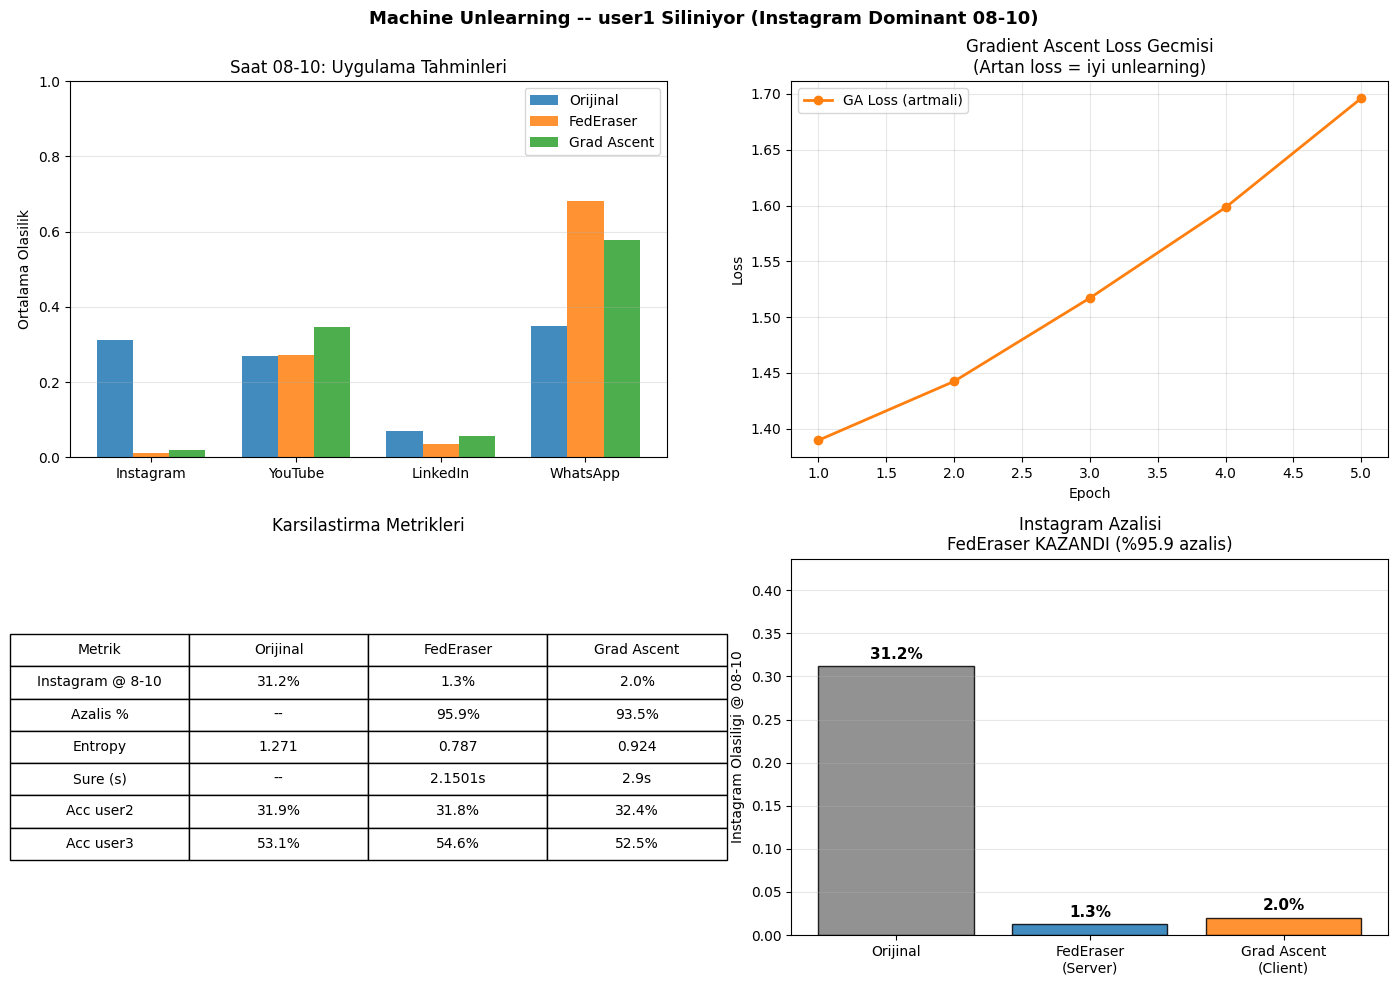

Grafik kaydedildi: results/comparison_plot.png


In [12]:

# ============================================================
# ASAMA 3: KARSILASTIRMA VE ANALIZ
# ============================================================
print("=" * 60)
print("  ASAMA 3: KARSILASTIRMA VE ANALIZ")
print("=" * 60)

# Saat 8-10 tahminleri (gercek verilerden)
orig_probs     = analyze_8_to_10_predictions(global_model,   FORGET_USER)
fedraser_probs = analyze_8_to_10_predictions(fedraser_model, FORGET_USER)
ga_probs       = analyze_8_to_10_predictions(ga_model,       FORGET_USER)

# Entropy
orig_entropy     = calculate_entropy(orig_probs)
fedraser_entropy = calculate_entropy(fedraser_probs)
ga_entropy       = calculate_entropy(ga_probs)

# Kalan client accuracy
remaining_acc = {}
for model_name, mdl in [
    ("original", global_model),
    ("fedraser",  fedraser_model),
    ("ga",        ga_model)
]:
    remaining_acc[model_name] = {u: calculate_accuracy(mdl, u) for u in REMAINING_USERS}

# Azalis %
orig_insta         = orig_probs["Instagram"]
fedraser_reduction = (orig_insta - fedraser_probs["Instagram"]) / orig_insta * 100
ga_reduction       = (orig_insta - ga_probs["Instagram"])       / orig_insta * 100

# ── Console ciktisi ──────────────────────────────────────────
print(f"\nSaat 08-10 Instagram Olasiliklari ({orig_probs['sample_count']} veri noktasi):")
print(f"  Orijinal    : {orig_insta:.1%}  (entropi: {orig_entropy:.3f})")
print(f"  FedEraser   : {fedraser_probs['Instagram']:.1%}  (entropi: {fedraser_entropy:.3f})")
print(f"  Grad Ascent : {ga_probs['Instagram']:.1%}  (entropi: {ga_entropy:.3f})")

print(f"\nAzalis yuzdeleri (Instagram @ 8-10):")
fedraser_ok = fedraser_reduction > 0
ga_ok       = ga_reduction       > 0
print(f"  FedEraser   : {'v' if fedraser_ok else '^'} {abs(fedraser_reduction):.1f}%  {'[OK]' if fedraser_ok else '[FAIL]'}")
print(f"  Grad Ascent : {'v' if ga_ok else '^'} {abs(ga_reduction):.1f}%  {'[OK]' if ga_ok else '[FAIL]'}")

print(f"\nFedEraser bilgi:")
print(f"  Toplam delta norm : {fedraser_results['total_delta_norm']:.4f}")
print(f"  Sure              : {fedraser_results['total_time']:.4f}s")

print(f"\nGradient Ascent bilgi:")
print(f"  Loss degisimi : {ga_results['loss_history'][0]:.4f} -> {ga_results['loss_history'][-1]:.4f}")
print(f"  Sure          : {ga_results['total_time']:.2f}s")

print(f"\nKalan Client Accuracy:")
for u in REMAINING_USERS:
    print(f"  {u}: Orig={remaining_acc['original'][u]:.1%} | FedEraser={remaining_acc['fedraser'][u]:.1%} | GA={remaining_acc['ga'][u]:.1%}")

winner         = "FedEraser" if fedraser_reduction > ga_reduction else "Gradient Ascent"
best_reduction = max(fedraser_reduction, ga_reduction)
print(f"\n{'='*60}")
print(f"  SONUC: {winner} DAHA BASARILI")
print(f"  Instagram etkisini %{best_reduction:.1f} oraninda sildi")
print(f"{'='*60}")

# ── JSON Raporu ───────────────────────────────────────────────
report = {
    "experiment_date": datetime.now().strftime("%Y-%m-%d"),
    "client_removed": FORGET_USER,
    "models": {
        "original": {**orig_probs, "entropy": orig_entropy},
        "fedraser": {
            **fedraser_probs, "entropy": fedraser_entropy,
            "reduction_percent": round(fedraser_reduction, 2),
            "execution_time_s": round(fedraser_results["total_time"], 4),
            "total_delta_norm": round(fedraser_results["total_delta_norm"], 4)
        },
        "ga": {
            **ga_probs, "entropy": ga_entropy,
            "reduction_percent": round(ga_reduction, 2),
            "execution_time_s": round(ga_results["total_time"], 2),
            "loss_history": ga_results["loss_history"]
        }
    },
    "remaining_clients_accuracy": remaining_acc,
    "conclusion": f"{winner} daha etkili (Instagram %{best_reduction:.1f} azaldi)"
}

with open("results/unlearning_results.json", "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2, ensure_ascii=False)
print("\nJSON raporu kaydedildi: results/unlearning_results.json")

# ── Visualization ─────────────────────────────────────────────
apps        = ["Instagram", "YouTube", "LinkedIn", "WhatsApp"]
models_data = [("Orijinal", orig_probs), ("FedEraser", fedraser_probs), ("Grad Ascent", ga_probs)]
x     = np.arange(len(apps))
width = 0.25

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Machine Unlearning -- {FORGET_USER} Siliniyor (Instagram Dominant 08-10)",
             fontsize=13, fontweight="bold")

# Subplot 1: App probs at 8-10
ax1 = axes[0, 0]
for i, (label, probs) in enumerate(models_data):
    ax1.bar(x + i * width, [probs[a] for a in apps], width, label=label, alpha=0.85)
ax1.set_xticks(x + width)
ax1.set_xticklabels(apps)
ax1.set_ylabel("Ortalama Olasilik")
ax1.set_title("Saat 08-10: Uygulama Tahminleri")
ax1.set_ylim(0, 1)
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

# Subplot 2: Gradient Ascent loss history
ax2 = axes[0, 1]
if ga_results["loss_history"]:
    ax2.plot(range(1, len(ga_results["loss_history"]) + 1),
             ga_results["loss_history"], "o-", color="tab:orange",
             label="GA Loss (artmali)", linewidth=2, marker="o")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.set_title("Gradient Ascent Loss Gecmisi\n(Artan loss = iyi unlearning)")
ax2.legend()
ax2.grid(alpha=0.3)

# Subplot 3: Metrics table
ax3 = axes[1, 0]
ax3.axis("off")
table_rows = [
    ["Instagram @ 8-10", f"{orig_insta:.1%}",             f"{fedraser_probs['Instagram']:.1%}", f"{ga_probs['Instagram']:.1%}"],
    ["Azalis %",         "--",                              f"{abs(fedraser_reduction):.1f}%",    f"{abs(ga_reduction):.1f}%"],
    ["Entropy",          f"{orig_entropy:.3f}",            f"{fedraser_entropy:.3f}",             f"{ga_entropy:.3f}"],
    ["Sure (s)",         "--",                              f"{fedraser_results['total_time']:.4f}s", f"{ga_results['total_time']:.1f}s"],
]
for u in REMAINING_USERS:
    table_rows.append([
        f"Acc {u}",
        f"{remaining_acc['original'][u]:.1%}",
        f"{remaining_acc['fedraser'][u]:.1%}",
        f"{remaining_acc['ga'][u]:.1%}",
    ])
tbl = ax3.table(cellText=table_rows,
                colLabels=["Metrik", "Orijinal", "FedEraser", "Grad Ascent"],
                loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)
ax3.set_title("Karsilastirma Metrikleri", pad=20)

# Subplot 4: Instagram reduction bar
ax4 = axes[1, 1]
model_labels = ["Orijinal", "FedEraser\n(Server)", "Grad Ascent\n(Client)"]
insta_vals   = [orig_insta, fedraser_probs["Instagram"], ga_probs["Instagram"]]
bar_clrs     = ["tab:gray", "tab:blue", "tab:orange"]
bars = ax4.bar(model_labels, insta_vals, color=bar_clrs, alpha=0.85, edgecolor="black")
ax4.set_ylabel("Instagram Olasiligi @ 08-10")
ax4.set_title(f"Instagram Azalisi\n{winner} KAZANDI (%{best_reduction:.1f} azalis)")
ax4.set_ylim(0, max(insta_vals) * 1.4)
for bar, val in zip(bars, insta_vals):
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f"{val:.1%}", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax4.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results/comparison_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafik kaydedildi: results/comparison_plot.png")


## 12. SISA Unlearning — Karşılaştırma Referansı

**SISA (Sharded, Isolated, Sliced, and Aggregated)** unlearning'in temel fikri: unutulması istenen client hiç dahil edilmeden model sıfırdan eğitilir. Bu, teorik "mükemmel" unlearning sonucunu verir.

Bu hücrede Federated Learning **yalnızca user2 ve user3** ile baştan eğitiliyor:

| Parametre | Değer |
|-----------|-------|
| Clients | user2, user3 (user1 yok) |
| Round | 6 |
| Local epochs | 20 |
| Batch size | 32 |
| Learning rate | 0.01 |
| Aggregation | FedAvg |

Bu model "gerçek" unlearning baseline'ı olarak client-based ve server-based yöntemlerle karşılaştırılır.

In [13]:
# ============================================================
# SISA UNLEARNING - Sifirdan Egitim (user1 olmadan)
# ============================================================
print("=" * 60)
print("  SISA UNLEARNING: FL yalnizca user2 + user3 ile")
print("=" * 60)

SISA_USERS = ["user2", "user3"]

torch.manual_seed(SEED)
np.random.seed(SEED)

sisa_global_model = AppUsageModel().to(device)
sisa_global_state = sisa_global_model.state_dict()

sisa_round_history = []
sisa_start_time = time.time()

for r in range(NUM_ROUNDS):
    print(f"\n  Round {r+1}/{NUM_ROUNDS}")
    client_states = []
    client_sizes  = []

    for user in SISA_USERS:
        window = user_windows[user][r]
        X, y   = window["X"], window["y"]
        state, acc, n = local_train(sisa_global_state, X, y,
                                    local_epochs=20, batch_size=32, lr=0.01)
        client_states.append(state)
        client_sizes.append(n)
        print(f"    {user}: {n} kayit | Local Acc: {acc*100:.1f}%")

    sisa_global_state = fed_avg(client_states, client_sizes)
    sisa_round_history.append({
        "round": r + 1,
        "state": copy.deepcopy(sisa_global_state)
    })

sisa_total_time = time.time() - sisa_start_time

sisa_global_model.load_state_dict(sisa_global_state)
sisa_global_model.eval()

print(f"\n{'='*60}")
print(f"  SISA EGITIMI TAMAMLANDI ({sisa_total_time:.4f} s)")
print(f"{'='*60}")

# 24 saat tahmin tablosu
sisa_results = predict_for_hours(sisa_global_model, range(24))
print()
print_predictions(sisa_results, title="  SISA Global Model - 24 Saat Tahmin Tablosu")


  SISA UNLEARNING: FL yalnizca user2 + user3 ile

  Round 1/6


    user2: 354 kayit | Local Acc: 43.8%


    user3: 371 kayit | Local Acc: 58.5%

  Round 2/6


    user2: 371 kayit | Local Acc: 43.9%


    user3: 352 kayit | Local Acc: 63.9%

  Round 3/6


...

    user2: 344 kayit | Local Acc: 44.2%


    user3: 365 kayit | Local Acc: 59.7%

  Round 5/6


    user2: 376 kayit | Local Acc: 47.1%
    user3: 365 kayit | Local Acc: 61.4%

  Round 6/6


    user2: 332 kayit | Local Acc: 49.1%


    user3: 361 kayit | Local Acc: 60.7%

  SISA EGITIMI TAMAMLANDI (3.4164 s)

  SISA Global Model - 24 Saat Tahmin Tablosu
  saat     tahmin guven   Insta     YT   Link     WA
 00:00  Instagram 36.7%   36.7%  25.0%   3.7%  34.5%
 01:00   WhatsApp 38.1%   32.9%  21.7%   7.3%  38.1%
 02:00   WhatsApp 42.0%   20.0%  25.5%  12.5%  42.0%
 03:00   WhatsApp 41.3%   11.5%  30.0%  17.2%  41.3%
 04:00   WhatsApp 38.9%   10.4%  34.9%  15.8%  38.9%
 05:00    YouTube 43.2%   10.3%  43.2%  12.1%  34.4%
 06:00    YouTube 49.7%   10.6%  49.7%   7.5%  32.2%
 07:00   WhatsApp 43.0%   19.6%  31.9%   5.5%  43.0%
 08:00   WhatsApp 56.7%    9.9%  26.9%   6.5%  56.7%
 09:00   WhatsApp 64.8%    7.6%  20.2%   7.4%  64.8%
 10:00   WhatsApp 50.7%    8.3%   9.2%  31.8%  50.7%
 11:00   LinkedIn 45.8%   12.4%   3.4%  45.8%  38.4%
 12:00   LinkedIn 41.1%   36.4%   4.3%  41.1%  18.2%
 13:00  Instagram 51.4%   51.4%   4.7%  27.7%  16.2%
 14:00  Instagram 34.3%   34.3%  12.6%  27.8%  25.3%
 15:00   WhatsApp 37.6%   13

  4 MODEL KARSILASTIRMASI (8-10 Instagram)

  Model                 Insta@8-10    Azalis   Entropy    u2 Acc    u3 Acc
  ------------------------------------------------------------------------
  Orijinal                   31.2%       ---     1.271     31.9%     53.1%
  FedEraser                   1.3%    v95.9%     0.787     31.8%     54.6%
  Grad Ascent                 2.0%    v93.5%     0.924     32.4%     52.5%
  SISA (Retrain)              8.4%    v73.0%     1.078     33.6%     49.0%

JSON raporu guncellendi: results/unlearning_results.json


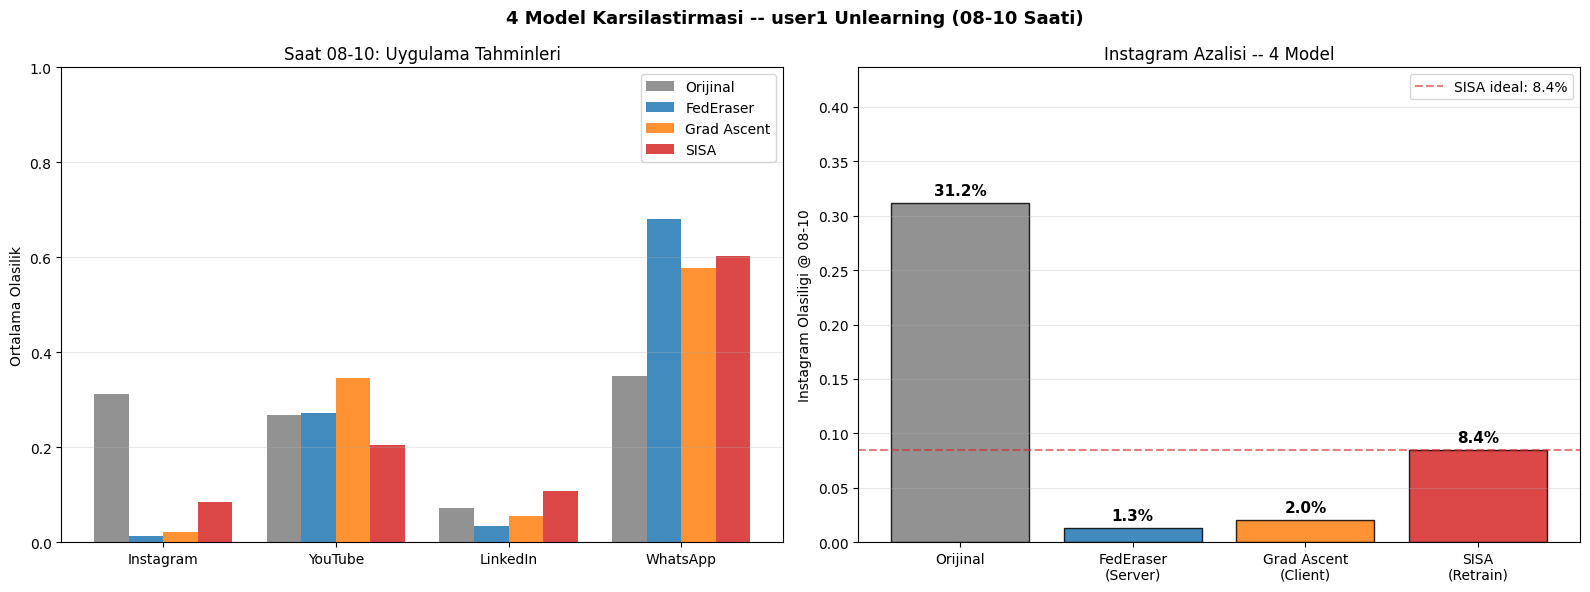

Grafik kaydedildi: results/comparison_with_sisa.png


In [14]:

# ============================================================
# SISA + TUM YONTEMLER KARSILASTIRMASI
# ============================================================
print("=" * 60)
print("  4 MODEL KARSILASTIRMASI (8-10 Instagram)")
print("=" * 60)

sisa_probs   = analyze_8_to_10_predictions(sisa_global_model, FORGET_USER)
sisa_entropy = calculate_entropy(sisa_probs)
sisa_acc     = {u: calculate_accuracy(sisa_global_model, u) for u in REMAINING_USERS}

orig_insta     = orig_probs["Instagram"]
sisa_reduction = (orig_insta - sisa_probs["Instagram"]) / orig_insta * 100

print(f"\n  {'Model':20s}  {'Insta@8-10':>10}  {'Azalis':>8}  {'Entropy':>8}  {'u2 Acc':>8}  {'u3 Acc':>8}")
print("  " + "-" * 72)
for label, probs, entropy, red, acc_dict in [
    ("Orijinal",       orig_probs,     orig_entropy,     0,                  remaining_acc["original"]),
    ("FedEraser",      fedraser_probs, fedraser_entropy, fedraser_reduction, remaining_acc["fedraser"]),
    ("Grad Ascent",    ga_probs,       ga_entropy,       ga_reduction,       remaining_acc["ga"]),
    ("SISA (Retrain)", sisa_probs,     sisa_entropy,     sisa_reduction,     sisa_acc),
]:
    arrow   = "v" if red > 0 else ("-" if red == 0 else "^")
    red_str = f"{arrow}{abs(red):.1f}%" if red != 0 else "---"
    print(f"  {label:20s}  {probs['Instagram']:>10.1%}  {red_str:>8}  "
          f"{entropy:>8.3f}  {acc_dict['user2']:>8.1%}  {acc_dict['user3']:>8.1%}")

# JSON raporuna SISA ekle
with open("results/unlearning_results.json", "r", encoding="utf-8") as f:
    report = json.load(f)

report["models"]["sisa_retrain"] = {
    **sisa_probs,
    "entropy": sisa_entropy,
    "reduction_percent": round(sisa_reduction, 2),
    "note": "Sifirdan egitim - user1 hic dahil edilmedi (ideal baseline)"
}
report["remaining_clients_accuracy"]["sisa"] = {u: sisa_acc[u] for u in REMAINING_USERS}

with open("results/unlearning_results.json", "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2, ensure_ascii=False)
print("\nJSON raporu guncellendi: results/unlearning_results.json")

# ── Karsilastirma Grafigi ─────────────────────────────────────
apps = ["Instagram", "YouTube", "LinkedIn", "WhatsApp"]
all_models = [
    ("Orijinal",    orig_probs),
    ("FedEraser",   fedraser_probs),
    ("Grad Ascent", ga_probs),
    ("SISA",        sisa_probs),
]
x     = np.arange(len(apps))
width = 0.2

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"4 Model Karsilastirmasi -- {FORGET_USER} Unlearning (08-10 Saati)",
             fontsize=13, fontweight="bold")

# Sol: Uygulama olasiliklari
ax1 = axes[0]
colors = ["tab:gray", "tab:blue", "tab:orange", "tab:red"]
for i, (label, probs) in enumerate(all_models):
    ax1.bar(x + i * width, [probs[a] for a in apps], width,
            label=label, color=colors[i], alpha=0.85)
ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(apps)
ax1.set_ylabel("Ortalama Olasilik")
ax1.set_title("Saat 08-10: Uygulama Tahminleri")
ax1.set_ylim(0, 1)
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

# Sag: Instagram azalis karsilastirmasi
ax2 = axes[1]
model_labels = ["Orijinal", "FedEraser\n(Server)", "Grad Ascent\n(Client)", "SISA\n(Retrain)"]
insta_vals   = [orig_probs["Instagram"], fedraser_probs["Instagram"],
                ga_probs["Instagram"], sisa_probs["Instagram"]]
bar_colors   = ["tab:gray", "tab:blue", "tab:orange", "tab:red"]
bars = ax2.bar(model_labels, insta_vals, color=bar_colors, alpha=0.85, edgecolor="black")
ax2.set_ylabel("Instagram Olasiligi @ 08-10")
ax2.set_title("Instagram Azalisi -- 4 Model")
ax2.set_ylim(0, max(insta_vals) * 1.4)
for bar, val in zip(bars, insta_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f"{val:.1%}", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax2.axhline(y=sisa_probs["Instagram"], color="tab:red", linestyle="--",
            alpha=0.6, label=f"SISA ideal: {sisa_probs['Instagram']:.1%}")
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results/comparison_with_sisa.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafik kaydedildi: results/comparison_with_sisa.png")


  24-SAAT TAHMINLER -- 4 MODEL KARSILASTIRMASI
  Forget user: user1

------------------------------------------------------------------------------
  OZET: Her saat icin DOMINANT tahmin (confidence %)
------------------------------------------------------------------------------
   Saat            Orijinal           FedEraser         Grad Ascent                SISA
  --------------------------------------------------------------------------
  00:00     Instagram 37.3%     Instagram 41.1%     Instagram 37.6%     Instagram 36.7%
  01:00     Instagram 44.7%     Instagram 36.2%      WhatsApp 33.0%      WhatsApp 38.1%
  02:00       YouTube 35.1%      WhatsApp 36.1%      WhatsApp 35.1%      WhatsApp 42.0%
  03:00      WhatsApp 38.9%      WhatsApp 36.6%      WhatsApp 38.0%      WhatsApp 41.3%
  04:00      WhatsApp 40.1%      WhatsApp 36.3%      WhatsApp 38.6%      WhatsApp 38.9%
  05:00      WhatsApp 39.3%      WhatsApp 35.3%      WhatsApp 37.3%       YouTube 43.2%
  06:00       YouTube 34.8%

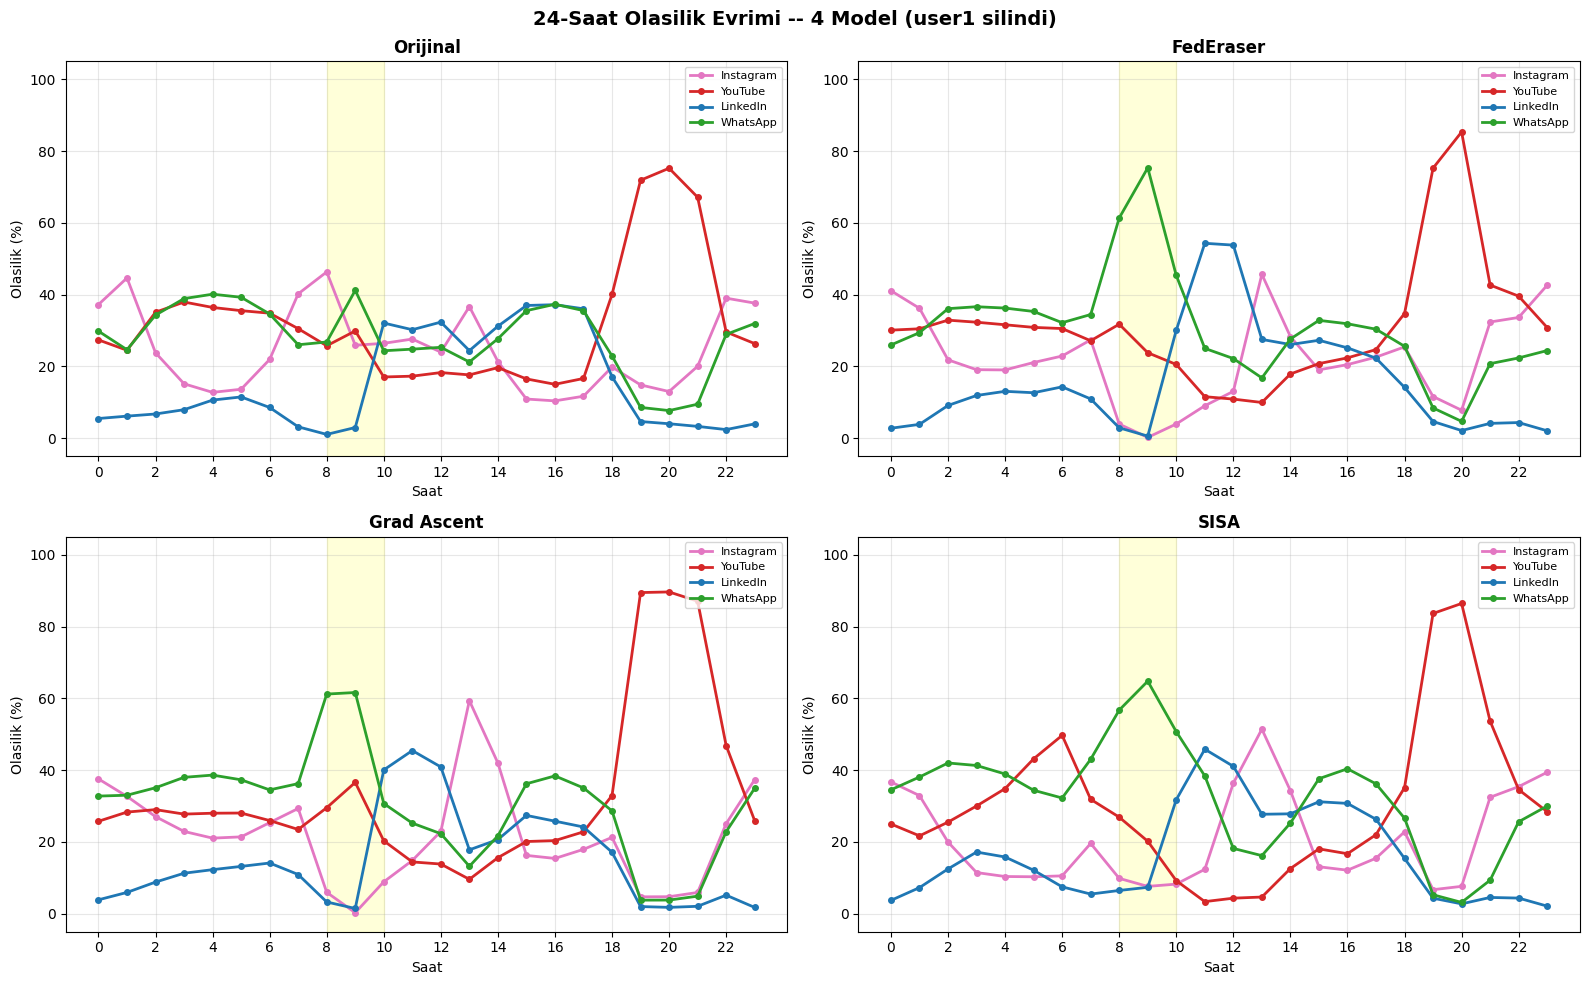

Grafik kaydedildi: results/hourly_predictions_4models.png


In [15]:
# ============================================================
# 24-SAAT SAAT BASI TAHMINLERI (4 MODEL)
# ============================================================
# Unlearning oncesi (orijinal) ve sonrasi (FedEraser, GA, SISA) modellerin
# 00:00..23:00 tum saat basi tahminlerini karsilastir.
# ============================================================

print("=" * 78)
print("  24-SAAT TAHMINLER -- 4 MODEL KARSILASTIRMASI")
print(f"  Forget user: {FORGET_USER}")
print("=" * 78)

hours = list(range(24))
model_predictions = {
    "Orijinal"   : predict_for_hours(global_model,     hours),
    "FedEraser"  : predict_for_hours(fedraser_model,   hours),
    "Grad Ascent": predict_for_hours(ga_model,         hours),
    "SISA"       : predict_for_hours(sisa_global_model, hours),
}

# --- 1) Ozet: her saat icin her modelin dominant tahmini ---
print("\n" + "-" * 78)
print("  OZET: Her saat icin DOMINANT tahmin (confidence %)")
print("-" * 78)
print(f"  {'Saat':>5}  {'Orijinal':>18}  {'FedEraser':>18}  {'Grad Ascent':>18}  {'SISA':>18}")
print("  " + "-" * 74)
for h in hours:
    row = f"  {h:02d}:00"
    for name in ["Orijinal", "FedEraser", "Grad Ascent", "SISA"]:
        r = model_predictions[name][h]
        cell = f"{r['prediction']:>10s} {r['confidence']*100:4.1f}%"
        row += f"  {cell:>18s}"
    print(row)

# --- 2) Detay: her model icin tam olasilik tablosu ---
for name in ["Orijinal", "FedEraser", "Grad Ascent", "SISA"]:
    print("\n" + "=" * 78)
    print(f"  DETAY: {name} -- 24 saat olasilik dagilimi")
    print("=" * 78)
    print_predictions(model_predictions[name])

# --- 3) Saat-bazli degisim haritasi ---
print("\n" + "=" * 78)
print("  SAAT-BAZLI DEGISIM HARITASI (orijinalden farkli olanlar)")
print("=" * 78)
print(f"  {'Saat':>5}  {'Orijinal':>12} -> {'FedEraser':>12}   {'Grad Ascent':>12}   {'SISA':>12}")
print("  " + "-" * 74)
diff_count = {"FedEraser": 0, "Grad Ascent": 0, "SISA": 0}
for h in hours:
    orig_pred = model_predictions["Orijinal"][h]["prediction"]
    fed_pred  = model_predictions["FedEraser"][h]["prediction"]
    ga_pred   = model_predictions["Grad Ascent"][h]["prediction"]
    sisa_pred = model_predictions["SISA"][h]["prediction"]

    if fed_pred  != orig_pred: diff_count["FedEraser"]   += 1
    if ga_pred   != orig_pred: diff_count["Grad Ascent"] += 1
    if sisa_pred != orig_pred: diff_count["SISA"]        += 1

    if fed_pred != orig_pred or ga_pred != orig_pred or sisa_pred != orig_pred:
        fed_mark  = fed_pred  if fed_pred  != orig_pred else "="
        ga_mark   = ga_pred   if ga_pred   != orig_pred else "="
        sisa_mark = sisa_pred if sisa_pred != orig_pred else "="
        print(f"  {h:02d}:00  {orig_pred:>12s} -> {fed_mark:>12s}   {ga_mark:>12s}   {sisa_mark:>12s}")

print("\n  Orijinalden farkli saat sayisi (24 ustunden):")
for name, cnt in diff_count.items():
    print(f"    {name:>12s}: {cnt:2d} saat ({cnt/24*100:.0f}%)")

# --- 4) JSON'a 24-saat tahminleri ekle ---
with open("results/unlearning_results.json", "r", encoding="utf-8") as f:
    report = json.load(f)

report["hourly_predictions"] = {
    name: [
        {
            "hour"      : r["hour"],
            "prediction": r["prediction"],
            "confidence": round(float(r["confidence"]), 4),
            "probs"     : {
                "Instagram": round(float(r["probs"][0]), 4),
                "YouTube"  : round(float(r["probs"][1]), 4),
                "LinkedIn" : round(float(r["probs"][2]), 4),
                "WhatsApp" : round(float(r["probs"][3]), 4),
            }
        }
        for r in model_predictions[name]
    ]
    for name in model_predictions
}
report["hourly_diff_count"] = diff_count

with open("results/unlearning_results.json", "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2, ensure_ascii=False)
print("\nJSON raporu guncellendi (hourly_predictions eklendi).")

# --- 5) 4 model x 4 app olasilik evrim grafigi ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f"24-Saat Olasilik Evrimi -- 4 Model ({FORGET_USER} silindi)",
             fontsize=14, fontweight="bold")

app_colors = {
    "Instagram": "tab:pink",
    "YouTube"  : "tab:red",
    "LinkedIn" : "tab:blue",
    "WhatsApp" : "tab:green",
}
model_axes = {
    "Orijinal"   : axes[0, 0],
    "FedEraser"  : axes[0, 1],
    "Grad Ascent": axes[1, 0],
    "SISA"       : axes[1, 1],
}

for name, ax in model_axes.items():
    preds = model_predictions[name]
    for app_idx, app_name in IDX_TO_LABEL.items():
        probs = [preds[h]["probs"][app_idx] * 100 for h in hours]
        ax.plot(hours, probs, marker="o", label=app_name,
                color=app_colors[app_name], linewidth=2, markersize=4)
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Saat")
    ax.set_ylabel("Olasilik (%)")
    ax.set_ylim(-5, 105)
    ax.set_xticks(range(0, 24, 2))
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, alpha=0.3)
    # Kritik 08-10 penceresini vurgula
    ax.axvspan(8, 10, alpha=0.15, color="yellow")

plt.tight_layout()
plt.savefig("results/hourly_predictions_4models.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafik kaydedildi: results/hourly_predictions_4models.png")


  PERFORMANS KARSILASTIRMASI - URETIM SURELERI

Yontem                                Step 1      Step 2      Toplam
  ------------------------------------------------------------------
  FedEraser (host)                  0.0009 s    2.1492 s    2.1501 s
  Grad Ascent (host)                0.3420 s    2.5465 s    2.8887 s
  SISA (host, baseline)                  ---         ---    3.4164 s
  GA Cihaz + Recovery host          0.2238 s    3.4338 s    3.6577 s

  --- Step 1 (saf silme adimi) karsilastirmasi ---
    FedEraser delta subtraction       0.0009 s  (1.00x)  xxxx
    GA on device (Kotlin, telefon)    0.2238 s  (255.16x)  xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
    GA on host (Python/PyTorch)       0.3420 s  (389.96x)  xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

  En hizli Step 1: FedEraser delta subtraction (0.0009 s)

  --- SISA (tam yeniden egitim) baseline'a kiyasla speedup ---
    FedEraser  :   1.6x daha hizli (sisa 3.42s vs 2.15s)
    GA (host)  :   1.2x daha hizli (sisa 3.4

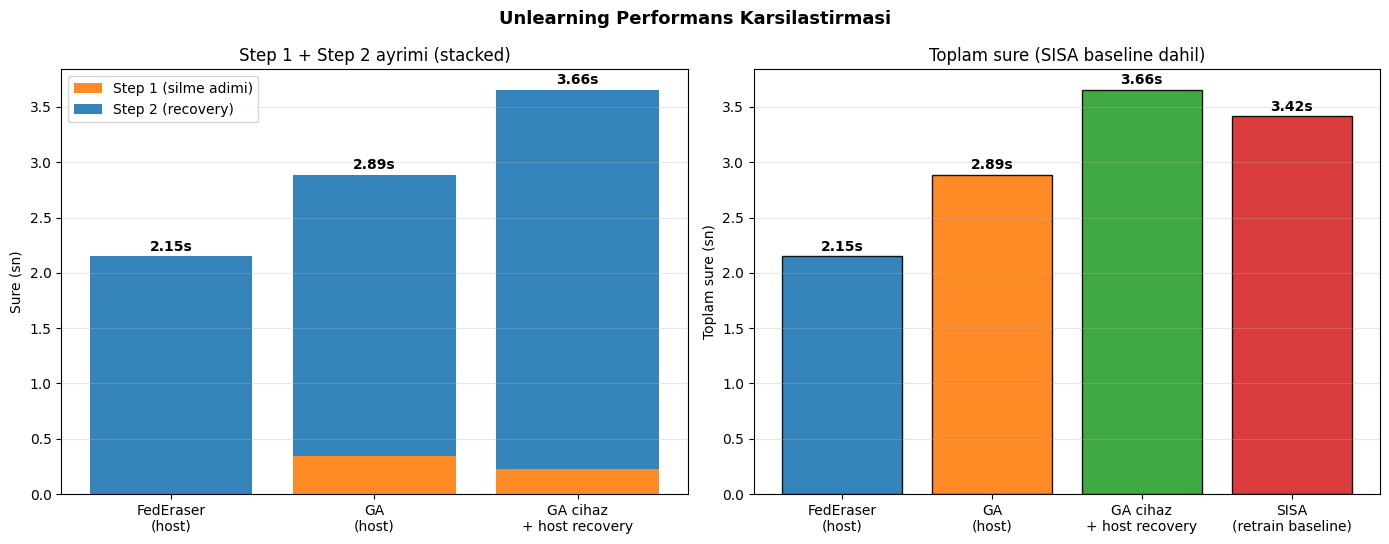

Grafik kaydedildi: results/performance_timing.png


In [16]:
# ============================================================
# PERFORMANS KARSILASTIRMASI - SUREler
# ============================================================
# Tum unlearning yontemlerinin (server-side ve client-side) Step 1
# (silme) ve Step 2 (recovery) surelerini yan yana karsilastirir.
# Cihaz pipeline'i (varsa) results/device_pipeline/ altinda olmali.
# ============================================================

import os, json
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print("  PERFORMANS KARSILASTIRMASI - URETIM SURELERI")
print("=" * 70)

# --- Host-side surelerini topla ---
fed_step1 = fedraser_results.get("step1_time")
fed_step2 = fedraser_results.get("step2_time")
fed_total = fedraser_results.get("total_time")

ga_step1  = ga_results.get("step1_time")
ga_step2  = ga_results.get("step2_time")
ga_total  = ga_results.get("total_time")

sisa_total = sisa_total_time if "sisa_total_time" in dir() else None

# --- Cihaz pipeline (varsa) ---
device_step1  = None
server_step2  = None
device_total  = None
device_metrics_path = "results/device_pipeline/ga_metrics.json"
device_final_path   = "results/device_pipeline/final_metrics.json"
if os.path.exists(device_metrics_path):
    with open(device_metrics_path, "r", encoding="utf-8") as f:
        dm = json.load(f)
    device_step1 = dm.get("total_time_seconds")
if os.path.exists(device_final_path):
    with open(device_final_path, "r", encoding="utf-8") as f:
        fm = json.load(f)
    server_step2 = fm.get("server_recovery", {}).get("total_time_seconds")
    device_total = fm.get("pipeline_total_time_seconds")

# --- Tablo basimi ---
print(f"\n{'Yontem':<32s}  {'Step 1':>10s}  {'Step 2':>10s}  {'Toplam':>10s}")
print("  " + "-" * 66)

def fmt(t):
    return "---" if t is None else f"{t:.4f} s"

print(f"  {'FedEraser (host)':<30s}  {fmt(fed_step1):>10s}  {fmt(fed_step2):>10s}  {fmt(fed_total):>10s}")
print(f"  {'Grad Ascent (host)':<30s}  {fmt(ga_step1):>10s}  {fmt(ga_step2):>10s}  {fmt(ga_total):>10s}")
print(f"  {'SISA (host, baseline)':<30s}  {'---':>10s}  {'---':>10s}  {fmt(sisa_total):>10s}")
print(f"  {'GA Cihaz + Recovery host':<30s}  {fmt(device_step1):>10s}  {fmt(server_step2):>10s}  {fmt(device_total):>10s}")

# --- Yorum ---
print(f"\n  --- Step 1 (saf silme adimi) karsilastirmasi ---")
items = [
    ("FedEraser delta subtraction", fed_step1),
    ("GA on host (Python/PyTorch)", ga_step1),
    ("GA on device (Kotlin, telefon)", device_step1),
]
items = [(n, t) for n, t in items if t is not None]
items.sort(key=lambda x: x[1])
fastest_name, fastest_time = items[0]
for n, t in items:
    rel = t / fastest_time
    bar = "x" * min(40, int(rel * 4))
    print(f"    {n:<32s}  {t:.4f} s  ({rel:.2f}x)  {bar}")
print(f"\n  En hizli Step 1: {fastest_name} ({fastest_time:.4f} s)")

if sisa_total and fed_total:
    speedup_fed = sisa_total / fed_total
    speedup_ga  = sisa_total / ga_total
    print(f"\n  --- SISA (tam yeniden egitim) baseline'a kiyasla speedup ---")
    print(f"    FedEraser  : {speedup_fed:5.1f}x daha hizli (sisa {sisa_total:.2f}s vs {fed_total:.2f}s)")
    print(f"    GA (host)  : {speedup_ga:5.1f}x daha hizli (sisa {sisa_total:.2f}s vs {ga_total:.2f}s)")

# --- JSON raporu ---
perf_report = {
    "host": {
        "fedraser": {"step1": fed_step1, "step2": fed_step2, "total": fed_total},
        "gradient_ascent": {"step1": ga_step1, "step2": ga_step2, "total": ga_total},
        "sisa": {"total": sisa_total},
    },
    "device_pipeline": {
        "device_ga_step1": device_step1,
        "host_recovery_step2": server_step2,
        "total": device_total,
    }
}
os.makedirs("results", exist_ok=True)
perf_path = "results/performance_timing.json"
with open(perf_path, "w", encoding="utf-8") as f:
    json.dump(perf_report, f, indent=2, ensure_ascii=False)
print(f"\n  JSON kaydedildi: {perf_path}")

# --- Grafik: Stacked bar (Step 1 + Step 2) ---
methods, step1_vals, step2_vals = [], [], []
for name, s1, s2 in [
    ("FedEraser\n(host)", fed_step1, fed_step2),
    ("GA\n(host)", ga_step1, ga_step2),
    ("GA cihaz\n+ host recovery", device_step1, server_step2),
]:
    if s1 is not None and s2 is not None:
        methods.append(name); step1_vals.append(s1); step2_vals.append(s2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle("Unlearning Performans Karsilastirmasi", fontsize=13, fontweight="bold")

ax1 = axes[0]
x = np.arange(len(methods))
ax1.bar(x, step1_vals, label="Step 1 (silme adimi)",     color="tab:orange", alpha=0.9)
ax1.bar(x, step2_vals, bottom=step1_vals, label="Step 2 (recovery)", color="tab:blue", alpha=0.9)
for i, (s1, s2) in enumerate(zip(step1_vals, step2_vals)):
    ax1.text(i, s1 + s2 + 0.05, f"{s1+s2:.2f}s", ha="center", fontweight="bold", fontsize=10)
ax1.set_xticks(x)
ax1.set_xticklabels(methods)
ax1.set_ylabel("Sure (sn)")
ax1.set_title("Step 1 + Step 2 ayrimi (stacked)")
ax1.legend(loc="upper left")
ax1.grid(axis="y", alpha=0.3)

ax2 = axes[1]
all_methods = list(methods)
all_totals  = [s1 + s2 for s1, s2 in zip(step1_vals, step2_vals)]
if sisa_total:
    all_methods.append("SISA\n(retrain baseline)")
    all_totals.append(sisa_total)
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"][:len(all_methods)]
bars = ax2.bar(all_methods, all_totals, color=colors, alpha=0.9, edgecolor="black")
for bar, t in zip(bars, all_totals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f"{t:.2f}s", ha="center", fontweight="bold")
ax2.set_ylabel("Toplam sure (sn)")
ax2.set_title("Toplam sure (SISA baseline dahil)")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results/performance_timing.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafik kaydedildi: results/performance_timing.png")
